This script plots activity obtained by MapMasks2AVI.ipynb notebook

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import copy
import h5py

In [2]:
h5add =  '/mnt/DATA/Mahsa/movies/LongRecordings/2024-09-17/W2tq9262/Activity_20240917_151717.h5'

In [3]:
h5data = h5py.File(h5add,'r')

In [4]:

print(h5data.attrs["name"])
print(h5data.attrs["neuron_Number"])

time = np.array(h5data["Time_series-s"])
Activity = np.zeros((3,len(time)))
Activity[0,:] = np.array(h5data["Mean_30perc/Red"])
Activity[2,:] = np.array(h5data["Mean_30perc/Green"])
Activity[1,:] = np.array(h5data["Mean_30perc/ratio"])
ActivityMax = np.zeros((3,len(time)))
ActivityMax[0,:] = np.array(h5data["Max/Red"])
ActivityMax[1,:] = np.array(h5data["Max/ratio"])
ActivityMax[2,:] = np.array(h5data["Max/Green"])
ActivityMean = np.zeros((3,len(time)))
ActivityMean[0,:] = np.array(h5data["Mean/Red"])
ActivityMean[2,:] = np.array(h5data["Mean/Green"])
ActivityMean[1,:] = np.array(h5data["Mean/ratio"])
VolumeTrack = np.array(h5data["Volume tracks"])

2024-09-17RIM
2


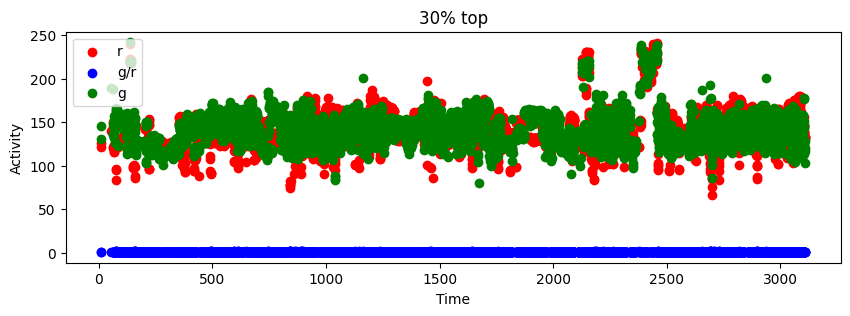

In [5]:

colors = ['r', 'blue', 'g','cyan']  # Red, Green, Blue
lab = ['r','g/r','g','b']

fig = plt.figure(figsize=(10,3))

for i in range(3):
    nonz = np.nonzero(ActivityMean[i, :])[0]
    plt.scatter(time[nonz], ActivityMean[i, nonz], color=colors[i], label=lab[i])

plt.xlabel('Time')
plt.ylabel('Activity')
plt.title('30% top')
plt.legend()
plt.show()

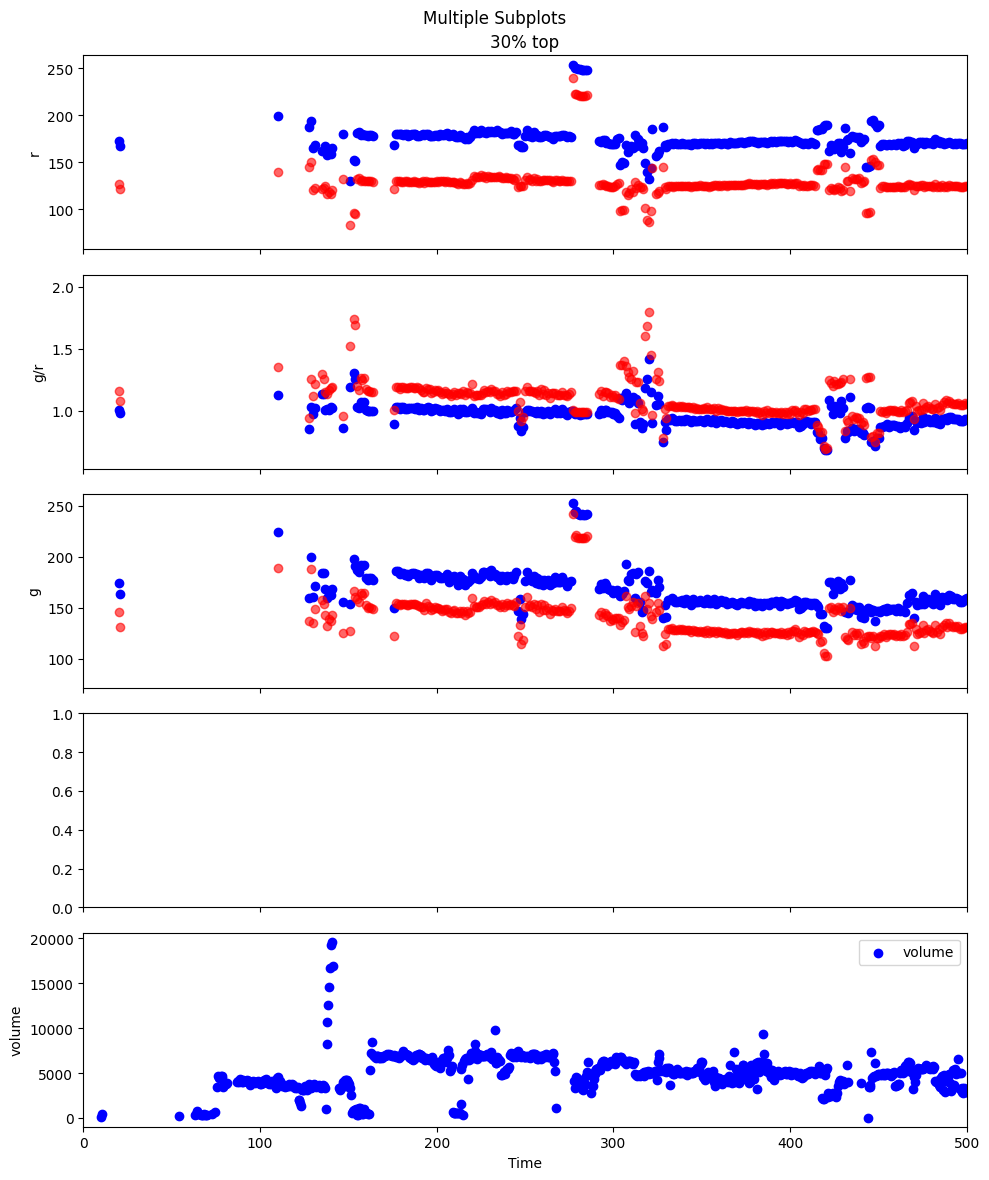

In [9]:
colors = ['r', 'blue', 'g','cyan']  # Red, Green, Blue
lab = ['r','g/r','g','b']
Limit=500
fig, axs = plt.subplots(5, 1,figsize = (10,12),sharex=True)  # 2x2 grid of subplots
fig.suptitle('Multiple Subplots')

for i in range(3):
    nonz = np.nonzero(Activity[i, :])[0]
    axs[i].scatter(nonz, Activity[i, nonz], color=colors[1], label='30%')
    nonz = np.nonzero(ActivityMean[i, :])[0]
    axs[i].scatter(nonz, ActivityMean[i, nonz], color=colors[0], label='mean',alpha=0.6)
    axs[i].set_ylabel(lab[i])
    axs[i].set_xlim(0,Limit)
nonz = np.nonzero(VolumeTrack)[0]
axs[4].scatter(time[nonz], VolumeTrack[nonz], color=colors[1], label='volume')

axs[4].set_xlabel('Time')
axs[4].set_ylabel('volume')
axs[0].set_title('30% top')
axs[4].set_xlim(0,Limit)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
h5data.close()